## EJERCICIO 1

--- Optimizando f1(x) con PSO ---


100%|██████████| 30/30 [00:00<00:00, 2630.81it/s]


Mínimo en x=420.9687 | f(x)=-418.9829

--- Optimizando f2(x,y) con PSO ---


100%|██████████| 50/50 [00:00<00:00, 1087.62it/s]

Mínimo en x=-0.0000, y=-0.0000 | f(x,y)=0.0000


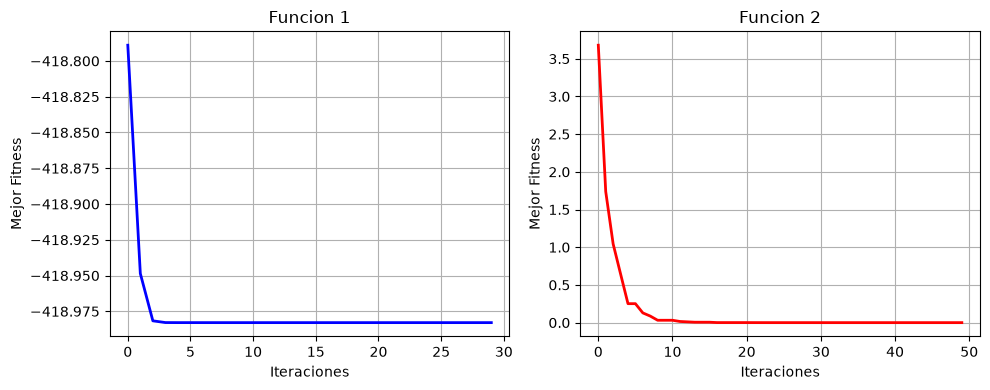

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import random
import copy
from tqdm import tqdm

# PARTICULA
class Particula:
    def __init__(self, limites):
        self.limites = limites
        self.dimensiones = len(limites)
        self.posicion = np.array([random.uniform(lim[0], lim[1]) for lim in limites])
        self.velocidad = np.zeros(self.dimensiones)
        
        # Memoria
        self.mejor_posicion = copy.deepcopy(self.posicion)
        self.mejor_fitness = None
        self.fitness = None

    def actualizar_velocidad(self, best_posicion, c1=1.5, c2=1.5):
        # movimiento del enjambre
        for i in range(self.dimensiones):
            r1 = random.random()
            r2 = random.random()
            
            atraccion_cognitiva = c1 * r1 * (self.mejor_posicion[i] - self.posicion[i])
            atraccion_social = c2 * r2 * (best_posicion[i] - self.posicion[i])
            self.velocidad[i] = atraccion_cognitiva + atraccion_social

    def actualizar_posicion(self):
        self.posicion += self.velocidad
        # evitar que no salga de los limites
        for i in range(self.dimensiones):
            self.posicion[i] = np.clip(self.posicion[i], self.limites[i][0], self.limites[i][1])


# ENJAMBRE
class EnjambrePSO:
    def __init__(self, funcion_objetivo, limites, tam_enjambre=30, iteraciones=100, c1=1.5, c2=1.5):
        self.funcion_objetivo = funcion_objetivo
        self.limites = limites
        self.tam_enjambre = tam_enjambre
        self.iteraciones = iteraciones
        
        self.c1 = c1  # Constante cognitiva 
        self.c2 = c2  # Constante social
        
        self.enjambre = []
        self.best_posicion = None
        self.best_fitness = None

    def inicializar_enjambre(self):
        self.enjambre = [Particula(self.limites) for _ in range(self.tam_enjambre)]
        for agente in self.enjambre:
            self.evaluar(agente)

    def evaluar(self, particula):
        particula.fitness = self.funcion_objetivo(particula.posicion)
        
        # Mejor Particula (local)
        if particula.mejor_fitness is None or particula.fitness < particula.mejor_fitness:
            particula.mejor_fitness = particula.fitness
            particula.mejor_posicion = copy.deepcopy(particula.posicion)
            
        # Mejor Enjambre (global)
        if self.best_fitness is None or particula.fitness < self.best_fitness:
            self.best_fitness = particula.fitness
            self.best_posicion = copy.deepcopy(particula.posicion)

    def ejecutar(self):
        self.inicializar_enjambre()
        historial_convergencia = []
            
        # Ciclo de vida 
        for _ in tqdm(range(self.iteraciones)):
            for particula in self.enjambre:
                particula.actualizar_velocidad(self.best_posicion, self.c1, self.c2)
                particula.actualizar_posicion()
                self.evaluar(particula)

            historial_convergencia.append(self.best_fitness)
                
        return self.best_posicion, self.best_fitness, historial_convergencia


def f1(x):
    val = x[0]
    return -val * np.sin(np.sqrt(np.abs(val)))

def f2(x):
    x_val, y_val = x[0], x[1]
    term1 = (x_val**2 + y_val**2)**0.25
    term2 = np.sin(50 * (x_val**2 + y_val**2)**0.1)**2 + 1
    return term1 * term2


if __name__ == "__main__":
    print("--- Optimizando f1(x) con PSO ---")
    pso1 = EnjambrePSO(f1, limites=[(-512, 512)], tam_enjambre=30, iteraciones=30)
    gbest_pos1, gbest_fit1, historial1 = pso1.ejecutar()
    print(f"Mínimo en x={gbest_pos1[0]:.4f} | f(x)={gbest_fit1:.4f}\n")

    print("--- Optimizando f2(x,y) con PSO ---")
    pso2 = EnjambrePSO(f2, limites=[(-100, 100), (-100, 100)], tam_enjambre=50, iteraciones=50)
    gbest_pos2, gbest_fit2, historial2= pso2.ejecutar()
    print(f"Mínimo en x={gbest_pos2[0]:.4f}, y={gbest_pos2[1]:.4f} | f(x,y)={gbest_fit2:.4f}")


    # GRAFICOS
    plt.figure(figsize=(10, 4))

    # f1
    plt.subplot(1, 2, 1)
    plt.plot(historial1, color='blue', linewidth=2)
    plt.title('Funcion 1')
    plt.xlabel('Iteraciones')
    plt.ylabel('Mejor Fitness')
    plt.grid(True)

    #  f2
    plt.subplot(1, 2, 2)
    plt.plot(historial2, color='red', linewidth=2)
    plt.title('Funcion 2')
    plt.xlabel('Iteraciones')
    plt.ylabel('Mejor Fitness')
    plt.grid(True)

    plt.tight_layout()
    plt.show()